In [2]:
# # remember to resteart kernell
# ! pip install -e ../../wazeasy
# ! pip install pandas "dask[complete]" pyarrow plotly
# ! pip install --upgrade s3fs
# ! pip install geopandas
# ! pip install seaborn
# ! pip install folium matplotlib mapclassifys
# ! pip install h3
# ! pip install dask-geopandas
# ! pip install folium matplotlib mapclassify

!rm -rf /tmp/*

In [2]:
# import os
# os.environ['AWS_CA_BUNDLE'] = '/Users/mtadeo/Documents/gitrepo/cacert_new.pem'
# os.environ['REQUESTS_CA_BUNDLE'] = '/Users/mtadeo/Documents/gitrepo/cacert_new.pem'

In [1]:
import pandas as pd
import dask.dataframe as dd
import dask_geopandas
from dask import delayed, compute
from wazeasy import utils, plots, reports
import geopandas as gpd
from shapely import Polygon
from h3 import LatLngPoly
import yaml
import altair as alt
alt.renderers.enable('mimetype')
import re

In [2]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

In [3]:
storage_options = {'profile': 'ddp',
    # 'client_kwargs': {
    #     'verify': '/Users/mtadeo/Documents/gitrepo/cacert_new.pem'
    #     }
                  }

# file_list = [
#     's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000000.parquet',
#     's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000001.parquet',
#     's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000002.parquet',
#     's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000003.parquet',
#     's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000004.parquet',
#     's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000005.parquet',
#     's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000006.parquet',
#     's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000007.parquet',
#     's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000008.parquet',
#     's3://wbg-waze/bq/IQ/682baghdad/jams/IQ_682baghdad_jams.000000000009.parquet'
# ]
# ddf = dd.read_parquet(file_list, storage_options = storage_options, engine = 'pyarrow')
# ddf = dd.read_parquet('s3://wbg-waze/bq/IQ/682baghdad/jams/*.parquet', 
#                       storage_options = storage_options, engine = 'pyarrow')

# path = 's3://wbg-waze/bq/IQ/682baghdad/jams/'
# df = pd.read_parquet(path, storage_options=storage_options)

In [4]:
%%time
path = 's3://wbg-waze/bq/IQ/595baghdad/jams/'
ddf = utils.load_data(path, 
                      storage_options = storage_options, file_type = 'parquet', 
                      filter_level_5 = True, 
                      usecols = ['ts', 'geoWKT', 'uuid', 'level','length'])
ddf = ddf.repartition(npartitions=80)
# ddf = ddf.repartition(npartitions=400)
# ddf = ddf.persist()
# ddf = ddf.compute()


CPU times: user 941 ms, sys: 101 ms, total: 1.04 s
Wall time: 2.19 s


In [5]:
timezone = config['Baghdad']['timezone']['timezone_name']
geographies = config['Baghdad']['geographies']
projected_crs = config['Baghdad']['crs']['projected_crs']

In [6]:
ddf = utils.assign_geography_to_jams(ddf)

In [7]:
utils.handle_time(ddf, timezone)

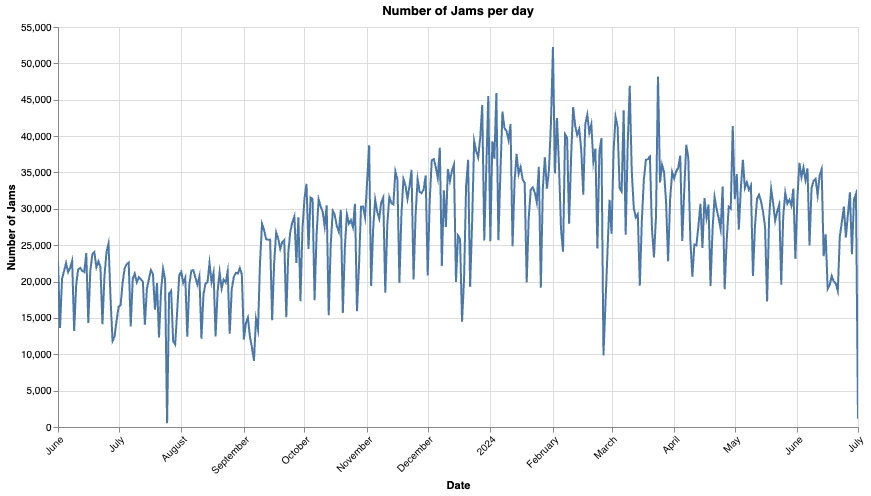

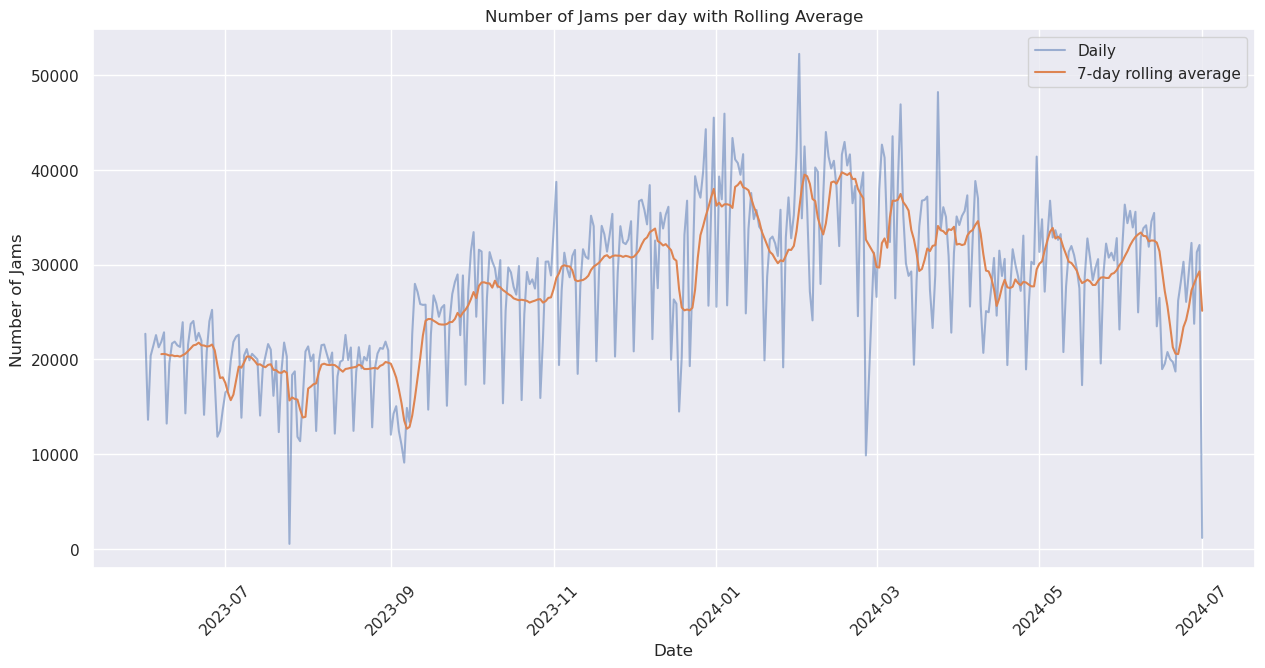

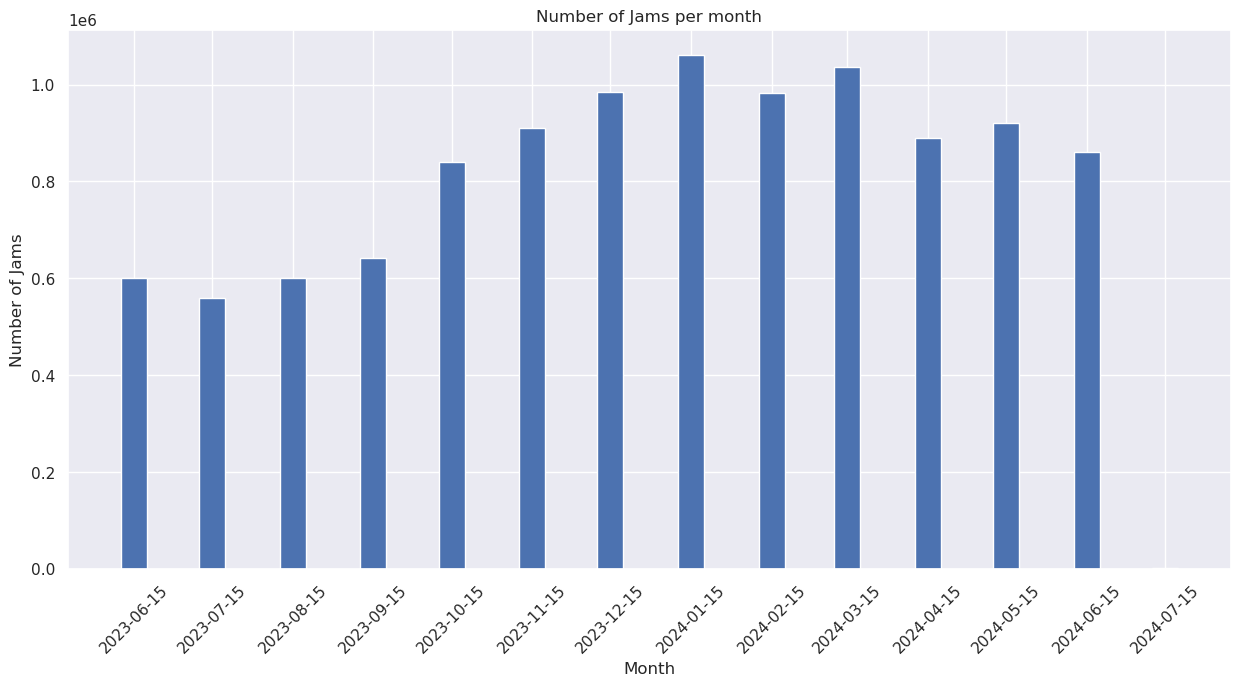

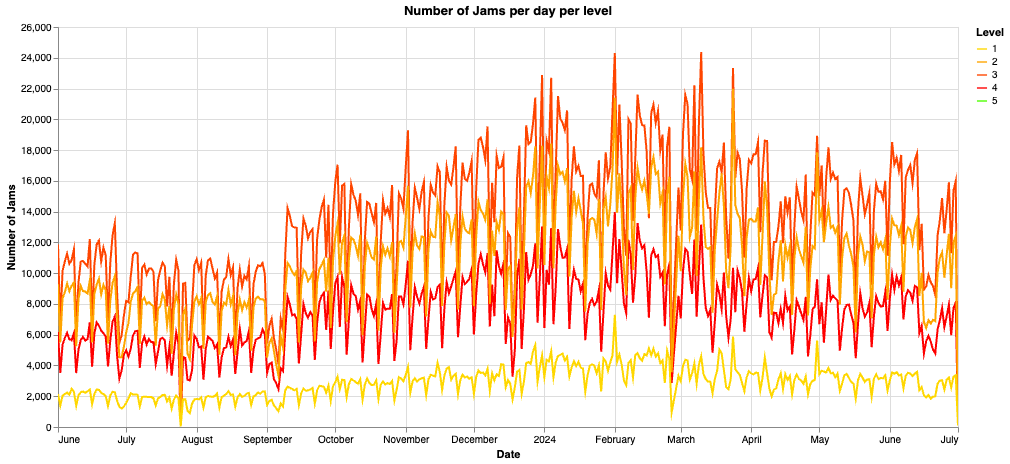

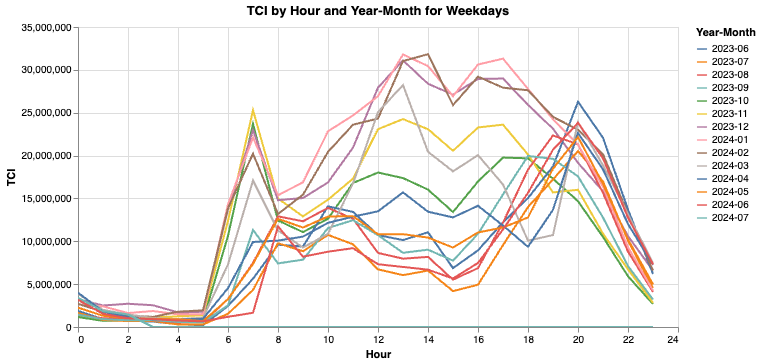

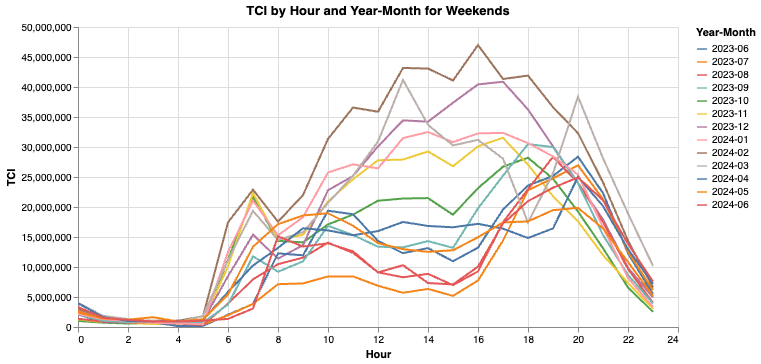

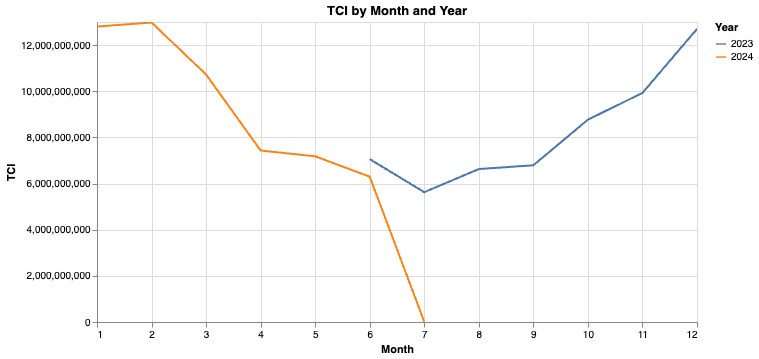

CPU times: user 17min 23s, sys: 4min 16s, total: 21min 39s
Wall time: 7min 43s


In [8]:
%%time
reports.run_basic_report(ddf, '2023-01-01', '2024-12-31')

Running report for Administrative Level 1


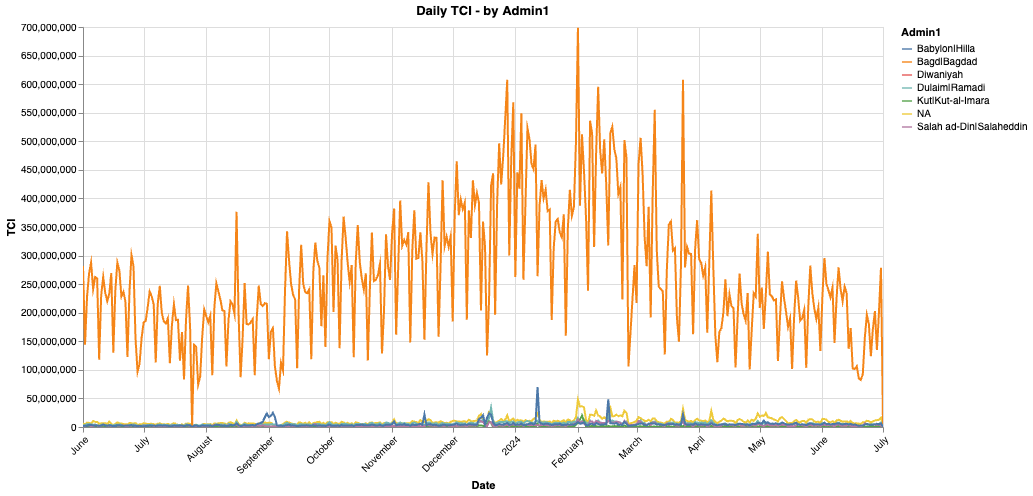

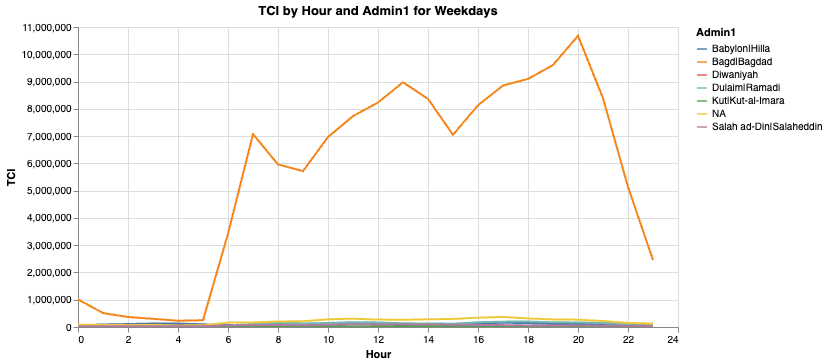

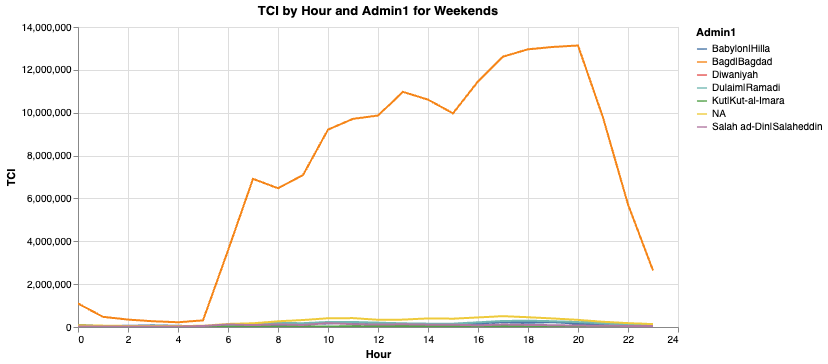

Running report for Administrative Level 2


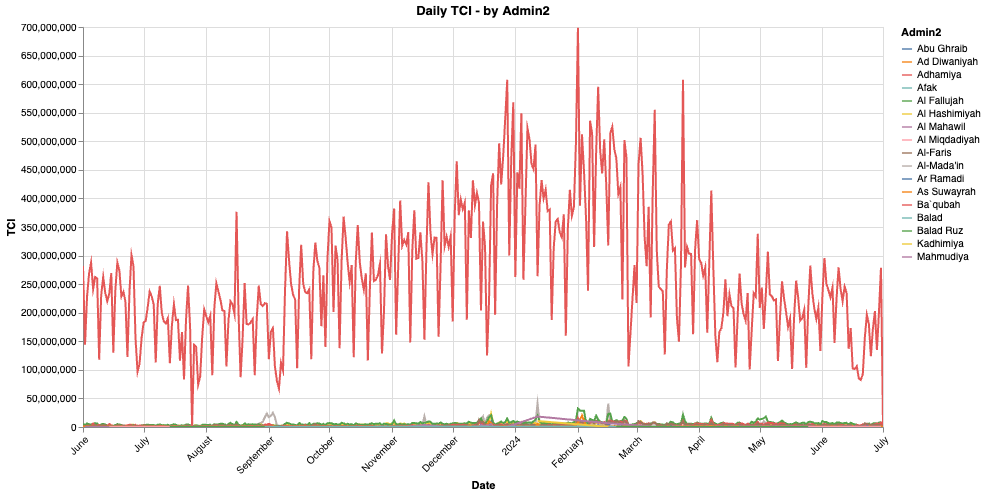

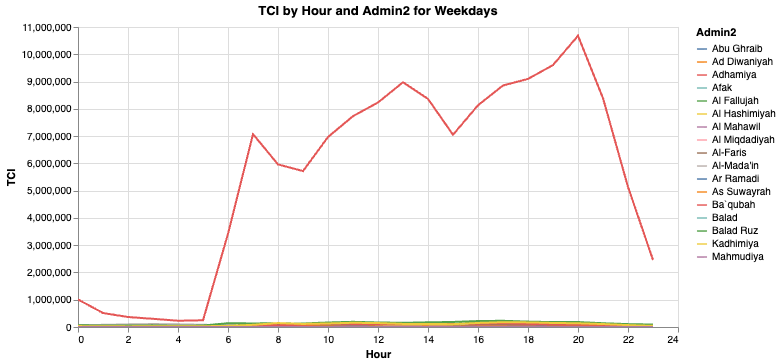

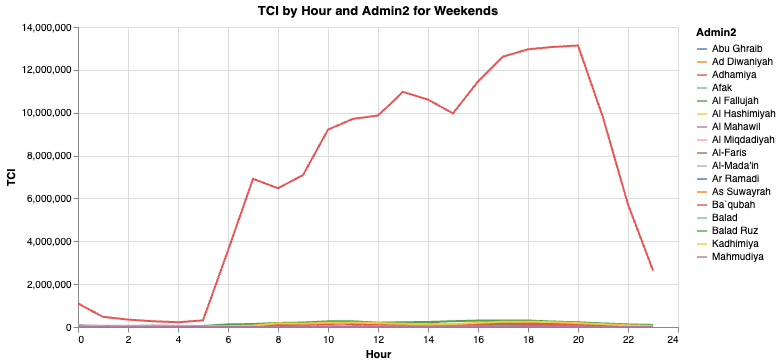

Running report for Hexagons Level 7


CPU times: user 48min 25s, sys: 22min 19s, total: 1h 10min 44s
Wall time: 23min 49s


In [18]:
%%time
reports.run_geog_report(ddf, geographies, '2023-01-01', '2024-12-31')

# Accidents